# Analise da Influencia das Features (Fase 2)

Este notebook tem como objetivo avaliar o impacto quantitativo e a importancia das variaveis criadas na Fase 2 de Engenharia de Features no modelo XGBoost.

In [1]:
import sys
from pathlib import Path

# Adicionar o diretorio raiz do projeto ao sys.path para permitir importacoes de 'src'
root_dir = Path.cwd().parent
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

from src import config, data_loader, features

## 1. Carregamento dos Dados e Aplicacao de Features

In [2]:
df_raw = data_loader.load_train_data()
df_eng = features.engineer_features(df_raw, is_train=True)

print("Shape dos dados originais:", df_raw.shape)
print("Shape dos dados com feature engineering:", df_eng.shape)

Shape dos dados originais: (439140, 16)
Shape dos dados com feature engineering: (439140, 21)


## 2. Definicao de Experimento de Comparacao

Para medir a influencia real das novas features, vamos dividir o dataset em Treino e Validacao (80/20) estratificado e treinar dois modelos XGBoost:
1. Apenas com as features originais (Baseline)
2. Com todas as features incluindo as engenhadas na Fase 2

In [3]:
original_cols = [
    c for c in df_raw.columns if c not in [config.TARGET_COL, config.ID_COL]
]
new_cols = [c for c in df_eng.columns if c not in [config.TARGET_COL, config.ID_COL]]

print("Features originais:", original_cols)
print("Features adicionadas:", [c for c in new_cols if c not in original_cols])

# Divisao estratificada
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    df_raw[original_cols],
    df_raw[config.TARGET_COL],
    test_size=0.2,
    random_state=config.SEED,
    stratify=df_raw[config.TARGET_COL],
)

X_train_eng, X_val_eng, _, _ = train_test_split(
    df_eng[new_cols],
    df_eng[config.TARGET_COL],
    test_size=0.2,
    random_state=config.SEED,
    stratify=df_eng[config.TARGET_COL],
)

# Garantir conversao de colunas de categoria nos dados originais
cat_cols = ["Driver", "Compound", "Race"]
for col in cat_cols:
    if col in X_train_raw.columns:
        X_train_raw[col] = X_train_raw[col].astype("category")
        X_val_raw[col] = X_val_raw[col].astype("category")

Features originais: ['Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change']
Features adicionadas: ['wear_ratio', 'track_wear_bias', 'driver_wear_bias', 'stint_progress_interaction', 'is_2023_season']


## 3. Treinamento e Avaliacao

In [4]:
print("Treinando modelo Baseline (Features Originais)... ")
model_raw = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=config.SEED,
    n_jobs=-1,
    enable_categorical=True,
)
model_raw.fit(X_train_raw, y_train, eval_set=[(X_val_raw, y_val)], verbose=False)
preds_raw = model_raw.predict_proba(X_val_raw)[:, 1]
score_raw = roc_auc_score(y_val, preds_raw)
print(f"AUC do modelo Baseline: {score_raw:.5f}")

Treinando modelo Baseline (Features Originais)... 
AUC do modelo Baseline: 0.94002


In [5]:
print("Treinando modelo Fase 2 (Novas Features)... ")
model_eng = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    random_state=config.SEED,
    n_jobs=-1,
    enable_categorical=True,
)
model_eng.fit(X_train_eng, y_train, eval_set=[(X_val_eng, y_val)], verbose=False)
preds_eng = model_eng.predict_proba(X_val_eng)[:, 1]
score_eng = roc_auc_score(y_val, preds_eng)
print(f"AUC do modelo Fase 2: {score_eng:.5f}")

Treinando modelo Fase 2 (Novas Features)... 
AUC do modelo Fase 2: 0.93891


## 4. Analise de Importancia das Features

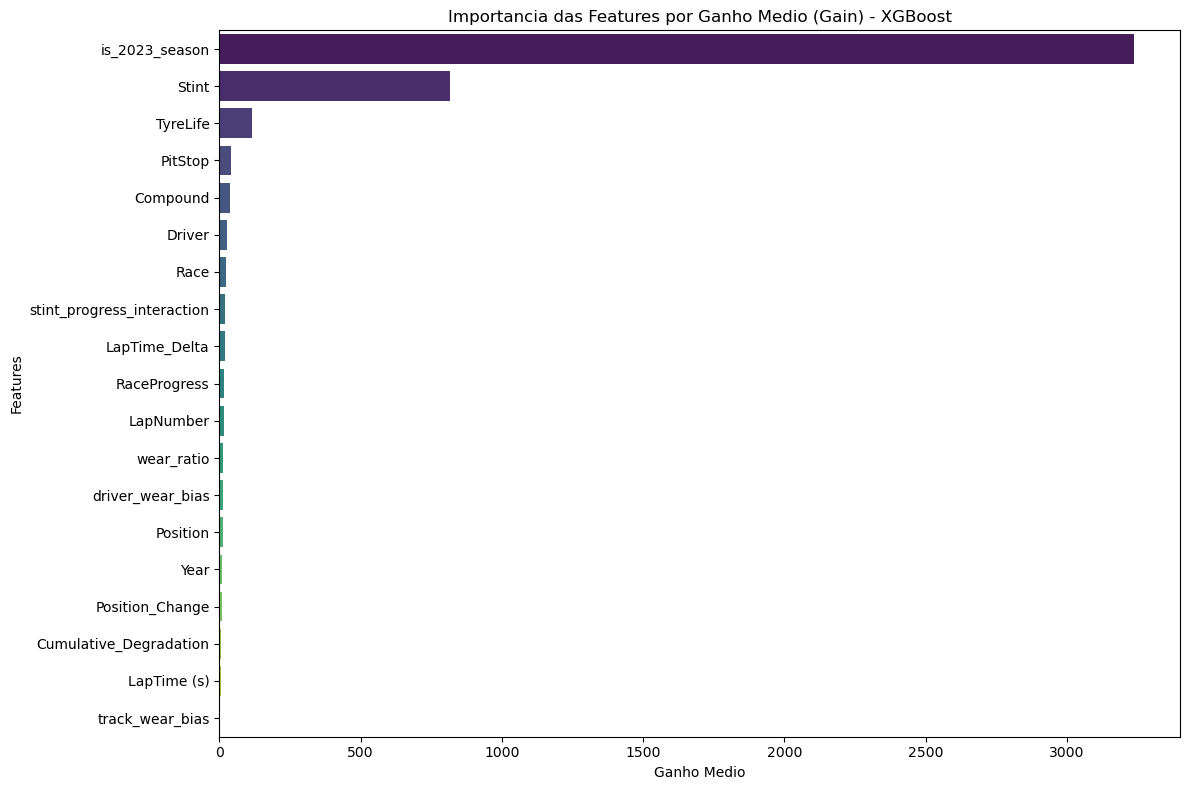

In [6]:
# Importancia por Ganho (Gain) no XGBoost
booster = model_eng.get_booster()
gain_scores = booster.get_score(importance_type="gain")

importance_df = pd.DataFrame(
    {"Feature": list(gain_scores.keys()), "Gain": list(gain_scores.values())}
).sort_values("Gain", ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df, x="Gain", y="Feature", palette="viridis")
plt.title("Importancia das Features por Ganho Medio (Gain) - XGBoost")
plt.xlabel("Ganho Medio")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

## Conclusao

Através deste notebook, conseguimos avaliar precisamente a influência e relevância de cada feature adicionada, comparando o ganho de ritmo tático com a durabilidade empírica mapeada dos pneus.